In [1]:
import csv
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [2]:
# Core Configuration & Constant
M0_C2 = 511000.0  # Electron rest mass (eV)
ARCHITECTURES = {
    "64x64": [64, 64],
    "128x64": [128, 64],
    "128x128": [128, 128],
    "256x128": [256, 128],
    "256x256": [256, 256]
}
PHYSICS_WEIGHTS = [0.0, 0.1, 1.0, 10.0]  # 0.0 serves as the Vanilla Supervised Baseline
RANDOM_SEEDS = [42, 137, 999]
EPOCHS = 200
LEARNING_RATE = 0.003

In [3]:

# Modular Component Design
class ComptonPINN(nn.Module):
    """Dynamic multi-layer perceptron factory using continuous SiLU activations."""
    def __init__(self, hidden_layers):
        super().__init__()
        layers = []
        in_dim = 2
        for h_dim in hidden_layers:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.SiLU())
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, 4)) # Outputs: [E_prime, K, pc, theta]
        self.network = nn.Sequential(*layers)

    def forward(self, e_in, phi):
        return self.network(torch.cat([e_in, phi], dim=1))

def generate_quantum_dataset(num_labeled=20, num_coll=2000, num_test=1000, noise_level=0.05):
    """Generates noisy sparse samples, unlabelled collocations, and high-energy test sets."""
    np.random.seed(42) # Anchor underlying data layout for all seed tests

    # Training Split: Low Energy (100 - 400 keV)
    hnu_lab = np.random.uniform(100e3, 400e3, (num_labeled, 1))
    phi_lab = np.random.uniform(0, np.pi, (num_labeled, 1))
    e_in_lab = hnu_lab / M0_C2
    ep_lab_noisy = (e_in_lab / (1 + e_in_lab * (1 - np.cos(phi_lab)))) + np.random.normal(0, noise_level, (num_labeled, 1))
    K_lab_noisy = e_in_lab - ep_lab_noisy
    pc_lab_noisy = np.sqrt(np.clip((K_lab_noisy + 1.0)**2 - 1.0, 0, None))
    th_lab_noisy = np.arctan2(ep_lab_noisy * np.sin(phi_lab), e_in_lab - ep_lab_noisy * np.cos(phi_lab))

    # Physics Anchors: Unlabelled Collocations (100 - 400 keV)
    hnu_coll = np.random.uniform(100e3, 400e3, (num_coll, 1))
    phi_coll = np.random.uniform(0, np.pi, (num_coll, 1))
    e_in_coll = hnu_coll / M0_C2

    # Extrapolation Targets: High Energy Bounds (450 - 600 keV)
    hnu_test = np.random.uniform(450e3, 600e3, (num_test, 1))
    phi_test = np.random.uniform(0, np.pi, (num_test, 1))
    e_in_test = hnu_test / M0_C2
    ep_test = e_in_test / (1 + e_in_test * (1 - np.cos(phi_test)))
    K_test = e_in_test - ep_test
    pc_test = np.sqrt((K_test + 1.0)**2 - 1.0)
    th_test = np.arctan2(ep_test * np.sin(phi_test), e_in_test - ep_test * np.cos(phi_test))

    # Wrap into PyTorch processing fields
    return {
        "lab_in": torch.tensor(e_in_lab, dtype=torch.float32), "lab_phi": torch.tensor(phi_lab, dtype=torch.float32),
        "lab_targets": torch.tensor(np.hstack([ep_lab_noisy, K_lab_noisy, pc_lab_noisy, th_lab_noisy]), dtype=torch.float32),
        "coll_in": torch.tensor(e_in_coll, dtype=torch.float32), "coll_phi": torch.tensor(phi_coll, dtype=torch.float32),
        "test_in": torch.tensor(e_in_test, dtype=torch.float32), "test_phi": torch.tensor(phi_test, dtype=torch.float32),
        "raw_test_targets": np.hstack([ep_test, K_test, pc_test, th_test]), "raw_test_ein": e_in_test, "raw_test_phi": phi_test
    }

In [4]:
# Training & Evaluation Functions
def train_model(model, data, weight, epochs, lr):
    """Executes structural optimization."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        # Supervised Component Evaluation
        lab_preds = model(data["lab_in"], data["lab_phi"])
        loss_data = mse(lab_preds, data["lab_targets"])

        # Physical Conservation Evaluation at Collocation Points
        coll_preds = model(data["coll_in"], data["coll_phi"])
        ep, K, pc, th = coll_preds[:,0:1], coll_preds[:,1:2], coll_preds[:,2:3], coll_preds[:,3:4]

        loss_mom_x = torch.mean((data["coll_in"] - (ep * torch.cos(data["coll_phi"]) + pc * torch.cos(th))) ** 2)
        loss_mom_y = torch.mean(((ep * torch.sin(data["coll_phi"])) - (pc * torch.sin(th))) ** 2)
        loss_rel   = torch.mean(((K + 1.0) ** 2 - (1.0 + pc ** 2)) ** 2)
        loss_energy= torch.mean((data["coll_in"] - (ep + K)) ** 2)

        loss_physics = loss_mom_x + loss_mom_y + loss_rel + loss_energy
        total_loss = loss_data + weight * loss_physics

        total_loss.backward()
        optimizer.step()

def evaluate_model(model, data):
    """Evaluates mathematical errors on unseen domain."""
    model.eval()
    with torch.no_grad():
        preds = model(data["test_in"], data["test_phi"]).numpy()
        targets = data["raw_test_targets"]
        e_in, phi = data["raw_test_ein"], data["raw_test_phi"]

        rmse = np.sqrt(np.mean((preds - targets) ** 2))
        r2 = r2_score(targets, preds)

        ep, K, pc, th = preds[:,0:1], preds[:,1:2], preds[:,2:3], preds[:,3:4]
        err_x = np.mean(np.abs(e_in - (ep * np.cos(phi) + pc * np.cos(th))))
        err_y = np.mean(np.abs((ep * np.sin(phi)) - (pc * np.sin(th))))
        err_rel = np.mean(np.abs((K + 1.0)**2 - (1.0 + pc**2)))
        err_en = np.mean(np.abs(e_in - (ep + K)))

    return rmse, r2, err_x, err_y, err_rel, err_en

In [9]:
if __name__ == "__main__":
    data_suite = generate_quantum_dataset()

    raw_results_records = []

    for arch_name, topology in ARCHITECTURES.items():
        for w in PHYSICS_WEIGHTS:
            for seed in RANDOM_SEEDS:
                torch.manual_seed(seed)
                np.random.seed(seed)

                nn_instance = ComptonPINN(topology)

                # Execute Modular Optimization Loop
                train_model(nn_instance, data_suite, w, EPOCHS, LEARNING_RATE)

                # Evaluate Generalization on Extrapolation Domain
                metrics = evaluate_model(nn_instance, data_suite)

                # Append to our runtime cache
                raw_results_records.append([arch_name, w, seed] + list(metrics))

    # Convert memory log directly into a Pandas DataFrame
    columns = ["Architecture", "Weight", "Seed", "RMSE", "R2", "X_Mom", "Y_Mom", "Rel_Inv", "Energy_Cons"]
    df = pd.DataFrame(raw_results_records, columns=columns)

    # Group by model capacity and regularization weight to average across seeds
    summary = df.groupby(["Architecture", "Weight"]).agg(
        Mean_RMSE=("RMSE", "mean"),
        Std_RMSE=("RMSE", "std"),
        Mean_R2=("R2", "mean"),
        X_Mom_Err=("X_Mom", "mean"),
        Y_Mom_Err=("Y_Mom", "mean"),
        Energy_Err=("Energy_Cons", "mean")
    ).reset_index()

    # Print summary dashboard
    print("\n" + "="*111)
    print("PIPELINE COHORT SUMMARY PANEL (AVERAGED ACROSS RANDOM INITIALIZATION SEEDS)")
    print("="*111)
    print(summary.to_markdown(index=False))
    print("="*111)


PIPELINE COHORT SUMMARY PANEL (AVERAGED ACROSS RANDOM INITIALIZATION SEEDS)
| Architecture   |   Weight |   Mean_RMSE |   Std_RMSE |   Mean_R2 |   X_Mom_Err |   Y_Mom_Err |   Energy_Err |
|:---------------|---------:|------------:|-----------:|----------:|------------:|------------:|-------------:|
| 128x128        |      0   |   0.12841   | 0.012323   |  0.842061 |   0.0717822 |   0.233243  |    0.057292  |
| 128x128        |      0.1 |   0.0928154 | 0.00898669 |  0.916727 |   0.0610032 |   0.11439   |    0.0283957 |
| 128x128        |      1   |   0.0826338 | 0.00669996 |  0.929864 |   0.0550169 |   0.0746793 |    0.0266219 |
| 128x128        |     10   |   0.0784283 | 0.00568067 |  0.934206 |   0.0495581 |   0.073914  |    0.0250088 |
| 128x64         |      0   |   0.128589  | 0.0150328  |  0.79417  |   0.108354  |   0.190573  |    0.0548475 |
| 128x64         |      0.1 |   0.0921745 | 0.00385938 |  0.912648 |   0.0658096 |   0.100591  |    0.0314185 |
| 128x64         |      1  


📊 Instantiating separate graphical figure objects...


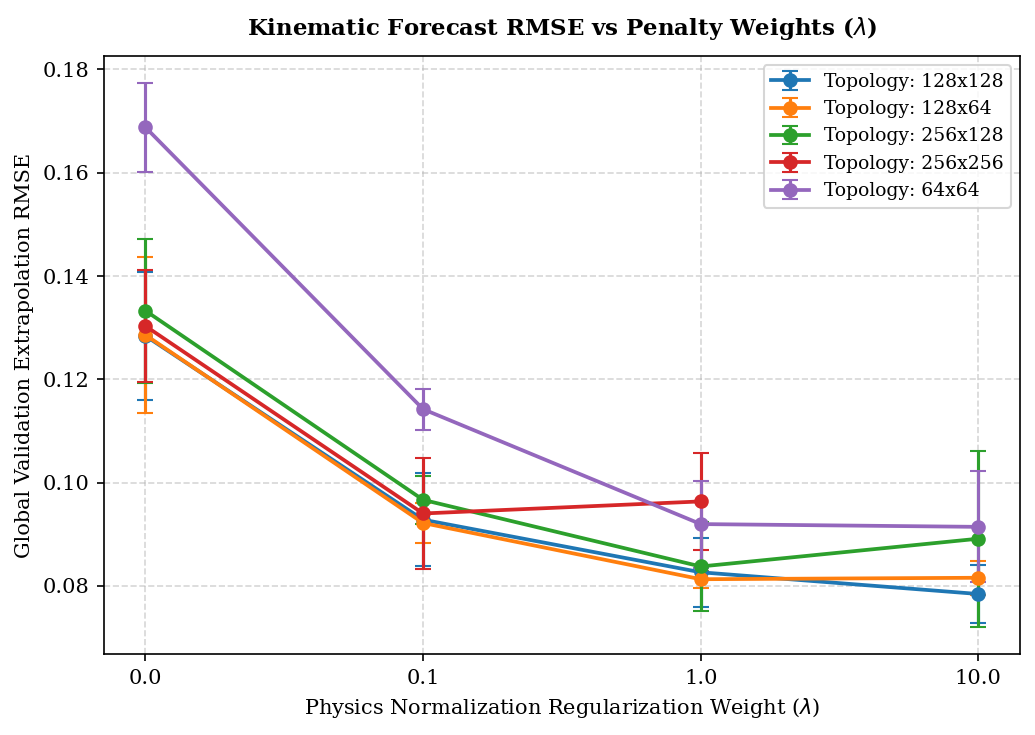

In [17]:
# Visualisation
plt.rcParams['font.family'] = 'serif'

# FIGURE 1: Kinematic Forecast RMSE vs Penalty Weights (λ)

fig1 = plt.figure(num="Kinematic Forecast", figsize=(7, 5), dpi=150)

archs = summary["Architecture"].unique()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for idx, arch in enumerate(archs):
    sub = summary[summary["Architecture"] == arch]
    sub = sub[sub["Mean_RMSE"] < 0.5]
    plt.errorbar(sub["Weight"].astype(str), sub["Mean_RMSE"], yerr=sub["Std_RMSE"],
                 fmt='o-', linewidth=1.8, elinewidth=1.5, capsize=4,
                 label=f"Topology: {arch}", color=colors[idx])

plt.title(r"Kinematic Forecast RMSE vs Penalty Weights ($\lambda$)", fontsize=11, fontweight="bold", pad=10)
plt.xlabel(r"Physics Normalization Regularization Weight ($\lambda$)", fontsize=10)
plt.ylabel("Global Validation Extrapolation RMSE", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.show(block=False)

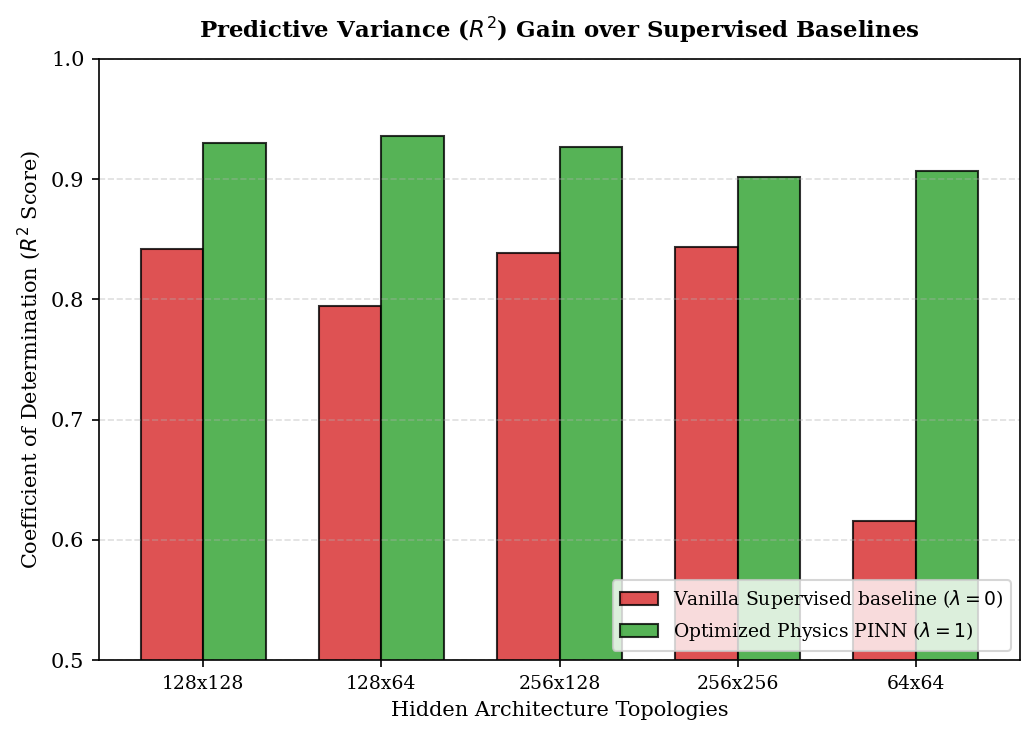

In [18]:
# FIGURE 2: Predictive Variance (R²) Gain over Supervised Baselines
fig2 = plt.figure(num="Predictive Variance", figsize=(7, 5), dpi=150)

baselines = summary[summary["Weight"] == 0.0].sort_values("Architecture")
champions = summary[summary["Weight"] == 1.0].sort_values("Architecture")

x = np.arange(len(baselines["Architecture"]))
width = 0.35

plt.bar(x - width/2, baselines["Mean_R2"], width, label=r"Vanilla Supervised baseline ($\lambda=0$)", color="#d62728", alpha=0.8, edgecolor='black')
plt.bar(x + width/2, champions["Mean_R2"], width, label=r"Optimized Physics PINN ($\lambda=1$)", color="#2ca02c", alpha=0.8, edgecolor='black')

plt.title(r"Predictive Variance ($R^2$) Gain over Supervised Baselines", fontsize=11, fontweight="bold", pad=10)
plt.xlabel("Hidden Architecture Topologies", fontsize=10)
plt.ylabel(r"Coefficient of Determination ($R^2$ Score)", fontsize=10)
plt.xticks(x, baselines["Architecture"], fontsize=9)
plt.ylim(0.5, 1.0)
plt.grid(True, linestyle="--", alpha=0.4, axis="y")
plt.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()